In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, normalize
sns.set_style('white')
%matplotlib inline

In [8]:
import kagglehub
path = kagglehub.dataset_download(handle="dev0914sharma/dataset")
print(path)

Using Colab cache for faster access to the 'dataset' dataset.
/kaggle/input/dataset


In [9]:
column_names = ['user_id', 'item_id', 'rating', 'timestamp']
df = pd.read_csv('/kaggle/input/dataset/Dataset.csv', sep=',', names=column_names, header=0)
movie_titles = pd.read_csv('/kaggle/input/dataset/Movie_Id_Titles.csv')
df = pd.merge(df, movie_titles, on='item_id')
df.head()

,user_id,item_id,rating,timestamp,title
0,0,50,5,881250949,Star Wars (1977)
1,0,172,5,881250949,"Empire Strikes Back, The (1980)"
2,0,133,1,881250949,Gone with the Wind (1939)
3,196,242,3,881250949,Kolya (1996)
4,186,302,3,891717742,L.A. Confidential (1997)


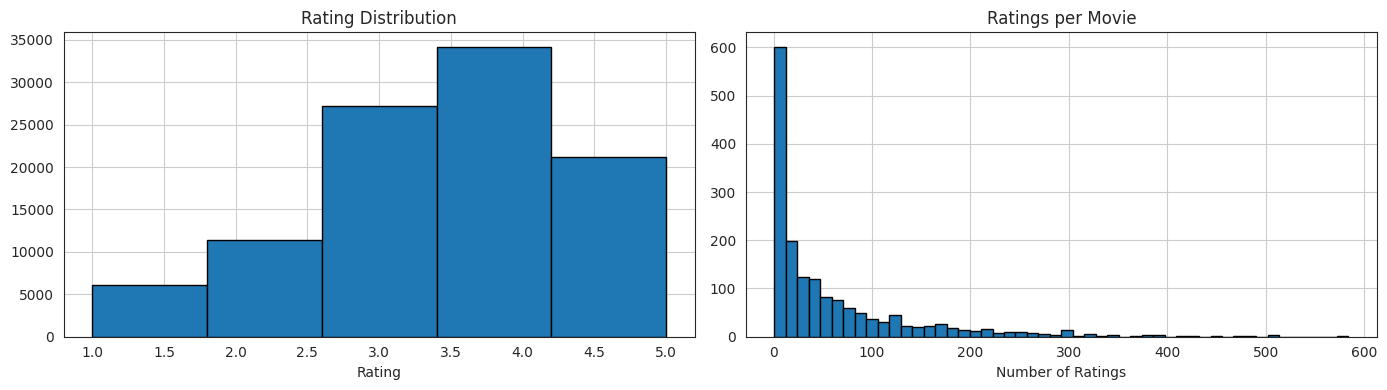

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['rating'].hist(bins=5, ax=axes[0], edgecolor='black')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')

df.groupby('title')['rating'].count().hist(bins=50, ax=axes[1], edgecolor='black')
axes[1].set_title('Ratings per Movie')
axes[1].set_xlabel('Number of Ratings')

plt.tight_layout()
plt.show()

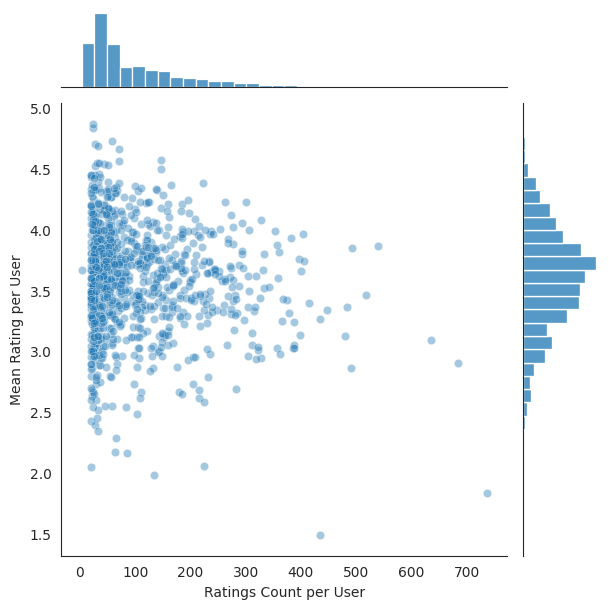

In [12]:
sns.jointplot(
    x=df.groupby('user_id')['rating'].count().values,
    y=df.groupby('user_id')['rating'].mean().values,
    alpha=0.4, height=6
)
plt.xlabel('Ratings Count per User')
plt.ylabel('Mean Rating per User')
plt.show()

In [14]:
user_enc = LabelEncoder()
movie_enc = LabelEncoder()

df['user_idx'] = user_enc.fit_transform(df['user_id'])
df['movie_idx'] = movie_enc.fit_transform(df['item_id'])

num_users = df['user_idx'].nunique()
num_movies = df['movie_idx'].nunique()
print(f'Users: {num_users} | Movies: {num_movies}')

df['rating_norm'] = (df['rating'] - 1) / 4.0

X_user = df['user_idx'].values
X_movie = df['movie_idx'].values
y = df['rating_norm'].values

(
    X_user_train, X_user_test,
    X_movie_train, X_movie_test,
    y_train, y_test
) = train_test_split(X_user, X_movie, y, test_size=0.2, random_state=42)

title_map = df[['item_id', 'title']].drop_duplicates().set_index('item_id')['title']

Users: 944 | Movies: 1682


In [15]:
EMBEDDING_DIM = 64

user_input = keras.Input(shape=(1,), name='user_input')
movie_input = keras.Input(shape=(1,), name='movie_input')

user_emb = layers.Embedding(num_users, EMBEDDING_DIM, name='user_embedding')(user_input)
movie_emb = layers.Embedding(num_movies, EMBEDDING_DIM, name='movie_embedding')(movie_input)

x = layers.Concatenate(axis=1)([user_emb, movie_emb])

x = layers.Conv1D(128, kernel_size=2, activation='relu', padding='same', name='conv1')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv1D(256, kernel_size=2, activation='relu', padding='same', name='conv2')(x)
x = layers.BatchNormalization()(x)
x = layers.GlobalMaxPooling1D(name='global_pool')(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid', name='rating_output')(x)

model = keras.Model(inputs=[user_input, movie_input], outputs=output)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_input          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_input         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 64)     │     60,416 │ user_input[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 64)     │    107,648 │ movie_input[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 2, 64)     │          0 │ user_embedding[0… │
│ (Concatenate)       │                   │            │ movie_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1 (Conv1D)      │ (None, 2, 128)    │     16,512 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 2, 128)    │        512 │ conv1[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2 (Conv1D)      │ (None, 2, 256)    │     65,792 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 2, 256)    │      1,024 │ conv2[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_pool         │ (None, 256)       │          0 │ batch_normalizat… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ global_pool[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_output       │ (None, 1)         │         65 │ dense_1[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 293,121 (1.12 MB)

 Trainable params: 292,353 (1.12 MB)

 Non-trainable params: 768 (3.00 KB)

In [16]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6
)

history = model.fit(
    [X_user_train, X_movie_train], y_train,
    validation_data=([X_user_test, X_movie_test], y_test),
    epochs=30,
    batch_size=256,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - loss: 0.0709 - mae: 0.2117 - val_loss: 0.0987 - val_mae: 0.2664 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0563 - mae: 0.1884 - val_loss: 0.0614 - val_mae: 0.2019 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0526 - mae: 0.1815 - val_loss: 0.0568 - val_mae: 0.1902 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.0500 - mae: 0.1766 - val_loss: 0.0567 - val_mae: 0.1896 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - loss: 0.0469 - mae: 0.1705 - val_loss: 0.0573 - val_mae: 0.1905 - learning_rate: 0.0010
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - loss: 0.0437 - mae: 0.1646 - val_loss: 0.0576 - val_mae: 0.1901 - learning_rate: 0.0010
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.0401 - mae: 0.1569 - val_loss: 0.0586 - val_mae: 0.1903 - learning_rate: 0.00

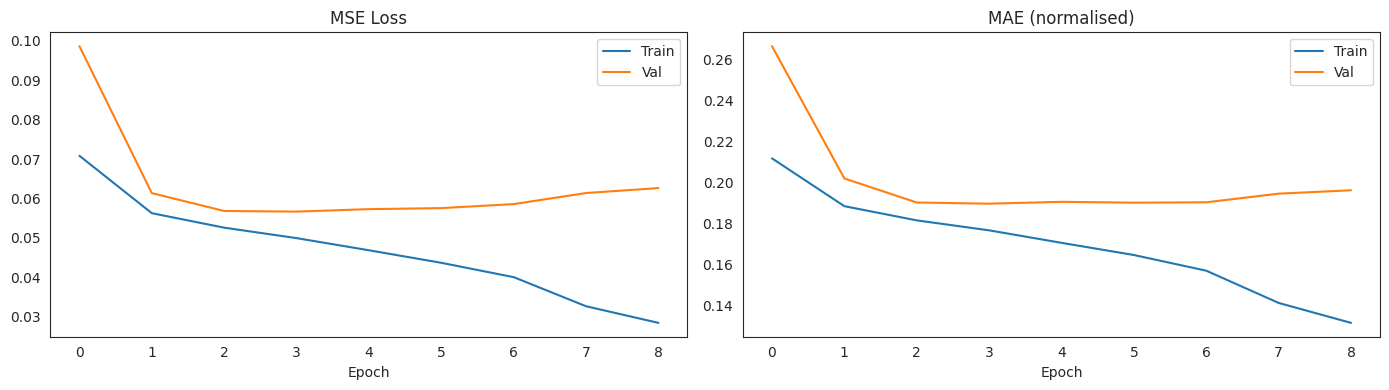

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('MSE Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train')
axes[1].plot(history.history['val_mae'], label='Val')
axes[1].set_title('MAE (normalised)')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
movie_weights = model.get_layer('movie_embedding').get_weights()[0]
movie_weights_norm = normalize(movie_weights, norm='l2')
print(f'Embedding matrix shape: {movie_weights_norm.shape}')

Embedding matrix shape: (1682, 64)


In [21]:
def find_similar_movies(query, top_n=10):
    if isinstance(query, str):
        matches = df[df['title'].str.lower() == query.lower()]['item_id']
        if matches.empty:
            close = df[df['title'].str.contains(query, case=False, na=False)]['title'].unique()
            if len(close):
                print(f'Exact match not found. Did you mean one of these?')
                for t in close[:5]:
                    print(f'  - {t}')
            else:
                print(f'No movie matching "{query}" found.')
            return None
        item_id_raw = matches.values[0]
    else:
        item_id_raw = query

    if item_id_raw not in movie_enc.classes_:
        print(f'Item ID {item_id_raw} not in training set.')
        return None

    m_idx = movie_enc.transform([item_id_raw])[0]
    query_vec = movie_weights_norm[m_idx]
    similarities = movie_weights_norm @ query_vec

    top_idxs = np.argsort(similarities)[::-1][1:top_n + 1]
    top_item_ids = movie_enc.inverse_transform(top_idxs)
    top_scores = similarities[top_idxs]

    input_title = title_map.get(item_id_raw, str(item_id_raw))
    results = pd.DataFrame({
        'rank': range(1, top_n + 1),
        'title': [title_map.get(iid, 'Unknown') for iid in top_item_ids],
        'item_id': top_item_ids,
        'cosine_similarity': top_scores
    }).set_index('rank')

    print(f'Top {top_n} movies similar to "{input_title}":\n')
    print(results.to_string())
    return results

In [29]:
find_similar_movies('Apollo 13 (1995)', top_n=10)

Top 10 movies similar to "Apollo 13 (1995)":

                                                   title  item_id  cosine_similarity
rank                                                                                
1                                 Wild Bunch, The (1969)      589           0.418282
2                                            Safe (1995)     1131           0.400174
3                                 Terminator, The (1984)      195           0.389661
4                             Waiting for Guffman (1996)     1007           0.359305
5                          Thieves (Voleurs, Les) (1996)     1462           0.352322
6                                       Game, The (1997)      333           0.347513
7                                       Lone Star (1996)      124           0.347298
8                           2001: A Space Odyssey (1968)      135           0.342579
9                        Replacement Killers, The (1998)      752           0.339010
10    Forbidden Chr

,title,item_id,cosine_similarity
rank,,,
1,"Wild Bunch, The (1969)",589,0.418282
2,Safe (1995),1131,0.400174
3,"Terminator, The (1984)",195,0.389661
4,Waiting for Guffman (1996),1007,0.359305
5,"Thieves (Voleurs, Les) (1996)",1462,0.352322
6,"Game, The (1997)",333,0.347513
7,Lone Star (1996),124,0.347298
8,2001: A Space Odyssey (1968),135,0.342579
9,"Replacement Killers, The (1998)",752,0.339010


In [27]:
find_similar_movies(50, top_n=20)

Top 20 movies similar to "Star Wars (1977)":

                                       title  item_id  cosine_similarity
rank                                                                    
1            Empire Strikes Back, The (1980)      172           0.502104
2                             Rob Roy (1995)      549           0.496372
3                        Sunset Blvd. (1950)      488           0.464164
4                  As Good As It Gets (1997)      316           0.431486
5                  African Queen, The (1951)      498           0.414612
6                 Usual Suspects, The (1995)       12           0.400861
7     Monty Python and the Holy Grail (1974)      168           0.400753
8                           Crossfire (1947)     1064           0.399753
9                    Hearts and Minds (1996)      868           0.389167
10                     Apocalypse Now (1979)      180           0.377195
11                     Love and a .45 (1994)     1077           0.362182
12   

,title,item_id,cosine_similarity
rank,,,
1,"Empire Strikes Back, The (1980)",172,0.502104
2,Rob Roy (1995),549,0.496372
3,Sunset Blvd. (1950),488,0.464164
4,As Good As It Gets (1997),316,0.431486
5,"African Queen, The (1951)",498,0.414612
6,"Usual Suspects, The (1995)",12,0.400861
7,Monty Python and the Holy Grail (1974),168,0.400753
8,Crossfire (1947),1064,0.399753
9,Hearts and Minds (1996),868,0.389167


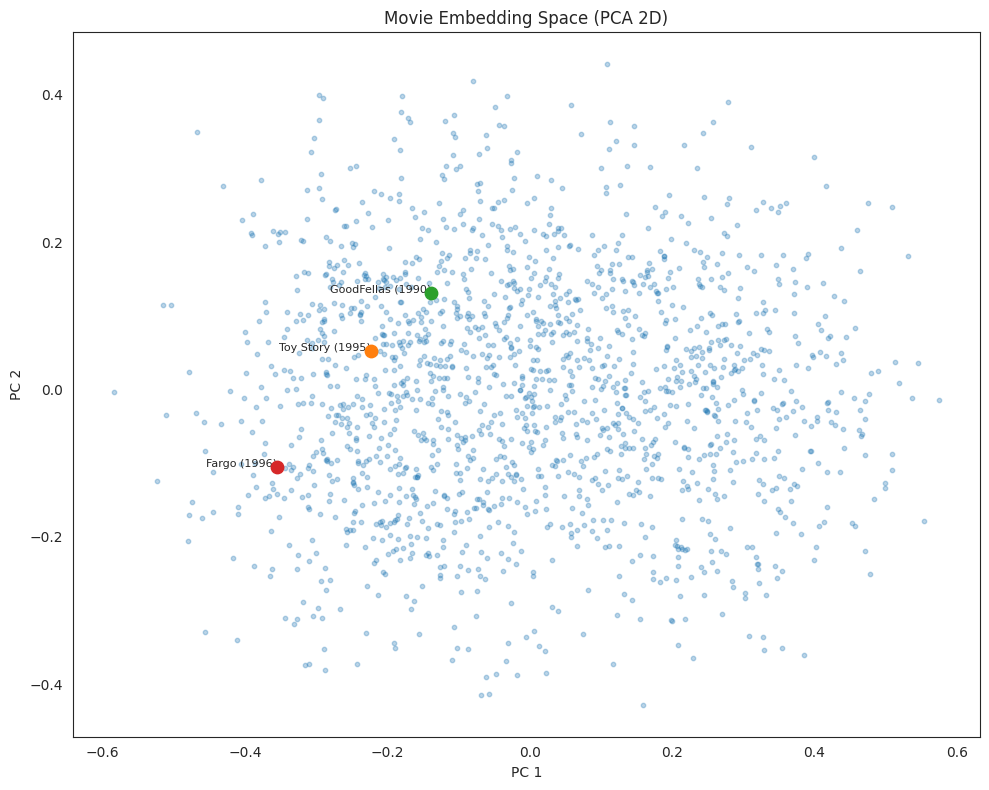

In [30]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(movie_weights_norm)

plt.figure(figsize=(10, 8))
plt.scatter(coords[:, 0], coords[:, 1], alpha=0.3, s=10)

highlight_titles = ['Toy Story (1995)', 'GoodFellas (1990)', 'Fargo (1996)']
for title in highlight_titles:
    matches = df[df['title'] == title]['item_id']
    if matches.empty or matches.values[0] not in movie_enc.classes_:
        continue
    idx = movie_enc.transform([matches.values[0]])[0]
    plt.scatter(coords[idx, 0], coords[idx, 1], s=80, zorder=5)
    plt.annotate(title, (coords[idx, 0], coords[idx, 1]), fontsize=8, ha='right')

plt.title('Movie Embedding Space (PCA 2D)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.tight_layout()
plt.show()